# **Sentiment Analysis from Movie Reviews**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
train_dataset = '/content/drive/MyDrive/Movie_Review_Dataset/train_movie_review.csv'
test_dataset ='/content/drive/MyDrive/Movie_Review_Dataset/test_movie_review.csv'
val_dataset='/content/drive/MyDrive/Movie_Review_Dataset/val_movie_review.csv'

**Text Preprocessing, Tokenization, and Sequence Padding:**

In [ ]:
df_train = pd.read_csv(train_dataset)
df_test = pd.read_csv(test_dataset)
df_val = pd.read_csv(val_dataset)

In [ ]:
df_train.head()

,Unnamed: 0,review,sentiment
0,3774,"Having avoided seeing the movie in the cinema,...",0
1,48396,With this movie I was really hoping that the i...,0
2,1980,Raymond Burr stars as an attorney caught up in...,0
3,6703,A lot people get hung up on this films tag as ...,1
4,28168,I was a fan of Buffy and hoped it would come t...,0


In [ ]:
print('Train Dataset Shape:', df_train.shape)
print('Test Dataset Shape:', df_test.shape)
print('Validation Dataset Shape:', df_val.shape)

Train Dataset Shape: (35000, 3)
Test Dataset Shape: (10000, 3)
Validation Dataset Shape: (5000, 3)


In [ ]:
# Checking nulls
print('Nulls on Train Dataset', df_train.isnull().sum())
print('Nulls on Test Dataset', df_test.isnull().sum())
print('Nulls on Validation Dataset', df_val.isnull().sum())

Nulls on Train Dataset Unnamed: 0    0
review        0
sentiment     0
dtype: int64
Nulls on Test Dataset Unnamed: 0    0
review        0
sentiment     0
dtype: int64
Nulls on Validation Dataset Unnamed: 0    0
review        0
sentiment     0
dtype: int64


No Null Data

In [ ]:
# Checking Duplicated
print('Duplicated on Train Dataset', df_train.duplicated().sum())
print('Duplicated on Test Dataset',df_test.duplicated().sum())
print('Duplicated on Validation Dataset',df_val.duplicated().sum())

Duplicated on Train Dataset 0
Duplicated on Test Dataset 0
Duplicated on Validation Dataset 0


No Duplicate Data

In [ ]:
# Removing Unamed:0 Column
df_train = df_train.drop('Unnamed: 0', axis=1)
df_test = df_test.drop('Unnamed: 0', axis=1)
df_val = df_val.drop('Unnamed: 0', axis=1)

In [ ]:
df_train['sentiment'].value_counts()

,count
sentiment,
0,17584
1,17416


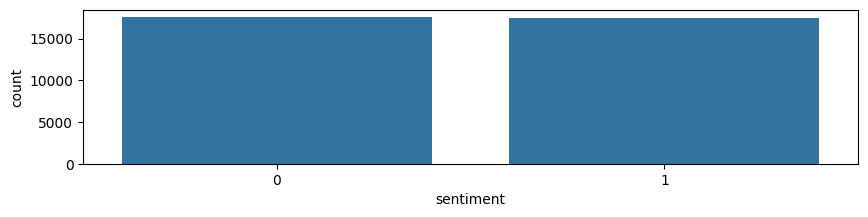

In [ ]:
plt.figure(figsize=(10,2))
sns.countplot(x='sentiment', data=df_train)
plt.show()

So balanced level class

Creating text cleaning functions

In [ ]:
import re

In [ ]:
def lower_text(text):
  return text.lower()

In [ ]:
def remove_url(text):
  return re.sub(r'https?://\S+|www\.\S+','',text)

In [ ]:
def remove_emoji(text):

  emoji_pattern = re.compile("["
                           u"\U0001F600-\U0001F64F"  # emoticons
                           u"\U0001F300-\U0001F5FF"  # symbols & pictographs
                           u"\U0001F680-\U0001F6FF"  # transport & map symbols
                           u"\U0001F1E0-\U0001F1FF"  # flags (iOS)
                           u"\U00002702-\U000027B0"
                           u"\U000024C2-\U0001F251"
                           "]+", flags=re.UNICODE)
  return emoji_pattern.sub(r' ', text)

In [ ]:
def remove_unwanted_characters(text):
  text = re.sub("@[A-Za-z0-9_]+"," ", text)
  # remove hashtags
  text = re.sub("#[A-Za-z0-9_]+","", text)
  # remove punctuation
  text = re.sub("[^0-9A-Za-z ]", "" , text)
  #remove emojis
  text = remove_emoji(text)
  # remove double spaces
  text = text.replace('  ',"")
  return text.strip()

In [ ]:
def remove_numbers(text):
  return re.sub(r'\d+', '', text)

Removing Stopwords

In [ ]:
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords
stop_words = set(stopwords.words('english'))
from nltk.tokenize import word_tokenize
nltk.download('punkt_tab')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [ ]:
negation_words = {"not", "no", "never", "nor", "neither", "none", "nobody", "nothing", "nowhere"}
stop_words = set(stopwords.words('english')) - negation_words

Tokenizing The Texts

In [ ]:
def tokenize_text(text):
  words_token = word_tokenize(text)
  return words_token

Removing Stopwords


In [ ]:
def remove_stopword(text_tokenized):
  cleaned_text = []
  for word in text_tokenized:
    if word not in stop_words:
      cleaned_text.append(word)
  return ' '.join(cleaned_text)

Lemminitazation

In [ ]:
from nltk.stem import WordNetLemmatizer
from nltk import pos_tag
from nltk.corpus import wordnet
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger')
nltk.download('averaged_perceptron_tagger_eng')
nltk.download('omw-1.4')

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [ ]:
# Lemmitizer with pos tag
lemmatizer = WordNetLemmatizer()

def get_pos_tag(word):
  tag = pos_tag([word])[0][1][0].upper()

  tag_dict = {
      "J":wordnet.ADJ,
      "N":wordnet.NOUN,
      "V":wordnet.VERB,
      "R":wordnet.ADV
  }

  return tag_dict.get(tag,wordnet.NOUN)

def lemmatize_word(text):
  words = text.split()

  lemmatized_words = []

  for word in words:
    pos = get_pos_tag(word)
    lemmatize = lemmatizer.lemmatize(word,pos)
    lemmatized_words.append(lemmatize)

  return ' '.join(lemmatized_words)

Defining the text cleaning pipeline

In [ ]:
def clean_text_pipeline(text):
  # Text Cleaning Part
  text = lower_text(text)
  text = remove_url(text)
  text = remove_numbers(text)
  text = remove_emoji(text)
  text = remove_unwanted_characters(text)
  text = tokenize_text(text) # Tokenize Text
  text = remove_stopword(text)
  text = lemmatize_word(text)
  return text


In [ ]:
df_train['review'] = df_train['review'].apply(clean_text_pipeline)

In [ ]:
df_test['review'] = df_test['review'].apply(clean_text_pipeline)

In [ ]:
df_val['review'] = df_val['review'].apply(clean_text_pipeline)

After all the text cleaning

In [ ]:
df_train

,review,sentiment
0,avoid see movie cinema buying dvd wife xmas wa...,0
1,movie really hop idea make hash together inept...,0
2,raymond burr star attorney caught murder best ...,0
3,lot people get hung film tag childrens film ce...,1
4,fan buffy hop would come proper end angel get ...,0
...,...,...
34995,one creepy underrated gem chill performance fa...,1
34996,final chapter hanzo razor trilogy provide fitt...,1
34997,saw movie say drive in day seem like would gre...,0
34998,cameron diaz woman married judge played harvey...,0


We will use train dataset for visualization because it will be the most used during model training

In [ ]:
from wordcloud import WordCloud

In [ ]:
all_words = " ".join(df_train['review'])

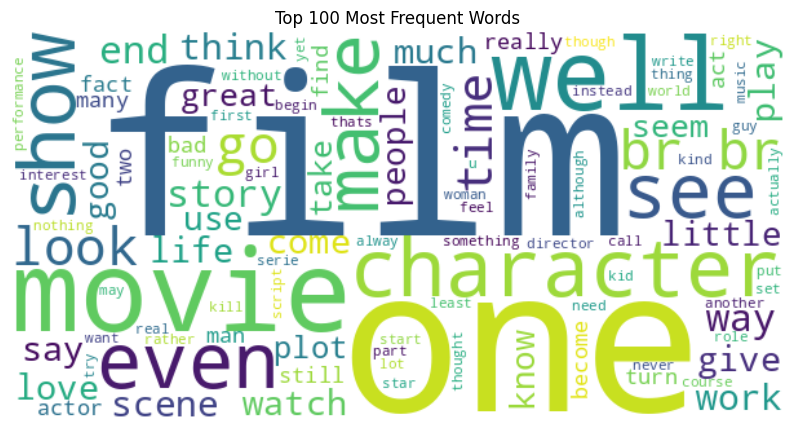

In [ ]:
word_cloud = WordCloud(
    width=600,
    height=300,
    background_color='white',
    max_words=100
).generate(all_words)

plt.figure(figsize=(10, 6))
plt.imshow(word_cloud, interpolation='bilinear')
plt.axis('off')
plt.title('Top 100 Most Frequent Words')
plt.show()

Tokenization and Padding

**Here since the dataset was already given in train test val form we do not need to do split function task**

In [ ]:
X_train = df_train['review']
y_train = df_train['sentiment']
X_test = df_test['review']
y_test = df_test['sentiment']
X_val = df_val['review']
y_val = df_val['sentiment']

Now tokenizing and padding the text

In [ ]:
print('Installing compatible versions of jax, jaxlib, and numpy to resolve potential conflicts...')
!pip install jax==0.4.23 jaxlib==0.4.23 'numpy<1.27' --upgrade --quiet
print('Installation complete. Please restart the runtime to apply the changes.')

Installing compatible versions of jax, jaxlib, and numpy to resolve potential conflicts...
Installation complete. Please restart the runtime to apply the changes.


In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

tokenizer = Tokenizer(num_words=10000, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)

In [ ]:
print ('Vocabulary Length:', len(tokenizer.word_index))
print('Example Sequence: ', len(X_train[100].split()))

Vocabulary Length: 162951
Example Sequence:  41


In [ ]:
X_train_sequences = tokenizer.texts_to_sequences(X_train)
X_test_sequences = tokenizer.texts_to_sequences(X_test)
X_val_sequences = tokenizer.texts_to_sequences(X_val)

Finding sequence lengths

In [ ]:
sequence_lengths = [len(seq) for seq in X_train_sequences]

max_len = int(np.percentile(sequence_lengths, 95))

print(max_len)

316


Now padding

In [ ]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

X_train_padded = pad_sequences(X_train_sequences, maxlen=max_len, padding='post', truncating='post')
X_test_padded = pad_sequences(X_test_sequences, maxlen=max_len, padding='post', truncating='post')
X_val_padded = pad_sequences(X_val_sequences, maxlen=max_len, padding='post', truncating='post')

In [ ]:
# Shape after padding
print('Train Dataset Shape:', X_train_padded.shape)
print('Test Dataset Shape:', X_test_padded.shape)
print('Validation Dataset Shape:', X_val_padded.shape)

Train Dataset Shape: (35000, 316)
Test Dataset Shape: (10000, 316)
Validation Dataset Shape: (5000, 316)


**Model Building and Training**

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN,Embedding, LSTM, Dense, Dropout,Input

In [ ]:
vocab_size = 20000
embedding_dim = 128
max_len = max_len


In [ ]:
y_train = np.array(y_train)
y_val = np.array(y_val)
y_test = np.array(y_test)

**Simple RNN**

In [ ]:
model_rnn = Sequential([
    Input(shape=(max_len,)),
    Embedding(input_dim=vocab_size,output_dim=embedding_dim,input_length=max_len),
    SimpleRNN(units=64, return_sequences=False,dropout=0.2, recurrent_dropout=0.2),
    Dense(64,activation='relu'),
    Dropout(0.2),
    Dense(1,activation='sigmoid')
])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [ ]:
model_rnn.compile(optimizer='adam',loss='binary_crossentropy', metrics=['accuracy'])


In [ ]:
model_rnn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 316, 128)       │     2,560,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 64)             │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,576,577 (9.83 MB)

 Trainable params: 2,576,577 (9.83 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from keras.callbacks import EarlyStopping

In [ ]:
earlystopping = EarlyStopping(monitor='val_loss',patience=4, verbose=1, restore_best_weights=True)

In [ ]:
history_rnn_v1 = model_rnn.fit(X_train_padded,y_train,validation_data=(X_val_padded,y_val),epochs=15,batch_size=32, callbacks=earlystopping)

Epoch 1/15
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 43s 28ms/step - accuracy: 0.5023 - loss: 0.7002 - val_accuracy: 0.5090 - val_loss: 0.6971
Epoch 2/15
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 27s 24ms/step - accuracy: 0.5033 - loss: 0.6959 - val_accuracy: 0.4862 - val_loss: 0.6951
Epoch 3/15
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 27s 24ms/step - accuracy: 0.5050 - loss: 0.6945 - val_accuracy: 0.4780 - val_loss: 0.6969
Epoch 4/15
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 28s 25ms/step - accuracy: 0.5005 - loss: 0.6941 - val_accuracy: 0.4934 - val_loss: 0.6939
Epoch 5/15
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 27s 24ms/step - accuracy: 0.5036 - loss: 0.6935 - val_accuracy: 0.4964 - val_loss: 0.6941
Epoch 6/15
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 27s 24ms/step - accuracy: 0.5038 - loss: 0.6934 - val_accuracy: 0.5070 - val_loss: 0.6949
Epoch 7/15
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 27s 24ms/step - accuracy: 0.5033 - loss: 0.6935 - val_accuracy: 0.4836 - val_loss: 0.6940
Epoch 8/15
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 41s 24ms/step - accuracy: 0.4996 -

Text(0, 0.5, 'Loss')

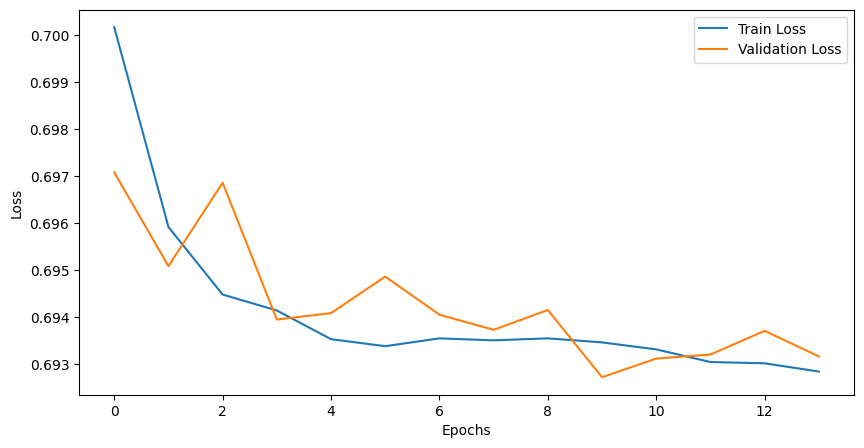

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(history_rnn_v1.history['loss'], label='Train Loss')
plt.plot(history_rnn_v1.history['val_loss'], label='Validation Loss')
plt.legend()
plt.xlabel('Epochs')
plt.ylabel('Loss')

In [ ]:
model_rnn.evaluate(X_test_padded,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.5064 - loss: 0.6928


[0.6927699446678162, 0.5063999891281128]

In [ ]:
y_pred_rnn_v1 = model_rnn.predict(X_test_padded)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step


In [ ]:
from sklearn.metrics import classification_report,accuracy_score, confusion_matrix

In [ ]:
print(classification_report(y_test, y_pred_rnn_v1.round()))

              precision    recall  f1-score   support

           0       0.50      0.76      0.60      4961
           1       0.52      0.26      0.35      5039

    accuracy                           0.51     10000
   macro avg       0.51      0.51      0.48     10000
weighted avg       0.51      0.51      0.47     10000



In [ ]:
print('Accuracy Score of Model is',accuracy_score(y_test, y_pred_rnn_v1.round()))

Accuracy Score of Model is 0.5064


In [ ]:
print('Confusion Matrix', confusion_matrix(y_test, y_pred_rnn_v1.round()))

Confusion Matrix [[3750 1211]
 [3725 1314]]


The model is performing very poorly in terms of accuracy and loss

Now we will use LSTM Model

**LSTM With Embeddings**

In [ ]:
lstm_model_v1 = Sequential([
    Input(shape=(max_len,)),
    Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_len),
    LSTM(128),

    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [ ]:
lstm_model_v1.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [ ]:
lstm_model_v1.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 316, 128)       │     2,560,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 128)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,699,905 (10.30 MB)

 Trainable params: 2,699,905 (10.30 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history_lstm_v1 = lstm_model_v1.fit(X_train_padded, y_train, validation_data=(X_val_padded, y_val), epochs=10, batch_size=32, callbacks=earlystopping)

Epoch 1/10
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 27s 21ms/step - accuracy: 0.5069 - loss: 0.6932 - val_accuracy: 0.4942 - val_loss: 0.6925
Epoch 2/10
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 20s 18ms/step - accuracy: 0.5206 - loss: 0.6852 - val_accuracy: 0.5136 - val_loss: 0.6930
Epoch 3/10
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 21s 19ms/step - accuracy: 0.5229 - loss: 0.6694 - val_accuracy: 0.4994 - val_loss: 0.7039
Epoch 4/10
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 41s 19ms/step - accuracy: 0.5532 - loss: 0.6534 - val_accuracy: 0.7446 - val_loss: 0.5878
Epoch 5/10
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 19s 18ms/step - accuracy: 0.8463 - loss: 0.3712 - val_accuracy: 0.8662 - val_loss: 0.3208
Epoch 6/10
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 20s 19ms/step - accuracy: 0.9187 - loss: 0.2224 - val_accuracy: 0.8854 - val_loss: 0.3046
Epoch 7/10
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 19s 18ms/step - accuracy: 0.9529 - loss: 0.1452 - val_accuracy: 0.8754 - val_loss: 0.3349
Epoch 8/10
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 20s 18ms/step - accuracy: 0.9723 -

Text(0, 0.5, 'Loss')

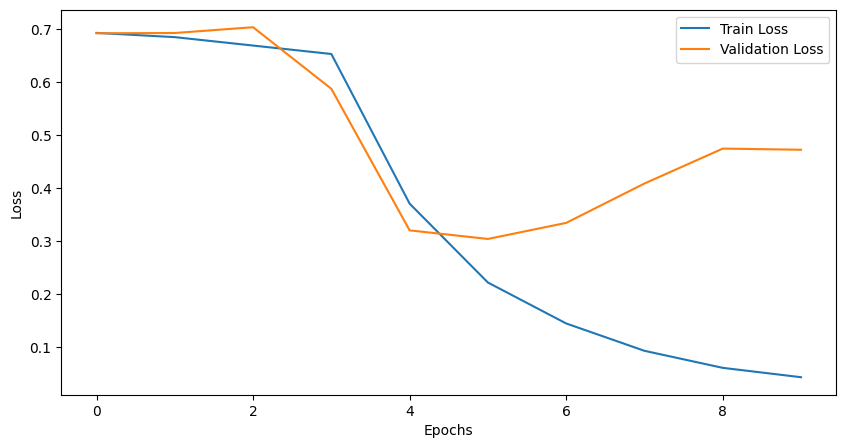

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(history_lstm_v1.history['loss'], label='Train Loss')
plt.plot(history_lstm_v1.history['val_loss'], label='Validation Loss')
plt.legend()
plt.xlabel('Epochs')
plt.ylabel('Loss')

In [ ]:
lstm_model_v1.evaluate(X_test_padded,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.8831 - loss: 0.3049


[0.3049338757991791, 0.8830999732017517]

In [ ]:
y_pred_lstm_v1 = lstm_model_v1.predict(X_test_padded)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step


In [ ]:
print(classification_report(y_test, y_pred_lstm_v1.round()))

              precision    recall  f1-score   support

           0       0.88      0.89      0.88      4961
           1       0.89      0.88      0.88      5039

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000



In [ ]:
print('Accuracy Score of Model is',accuracy_score(y_test, y_pred_lstm_v1.round()))

Accuracy Score of Model is 0.8831


In [ ]:
print('Confusion Matrix', confusion_matrix(y_test, y_pred_lstm_v1.round()))

Confusion Matrix [[4409  552]
 [ 617 4422]]


The model is overfitting with train accuracy of 0.99 and test accuracy of 0.88. But to prevent further overfitting earlystop was applied

**LSTM with word2vec**

In [ ]:
import gensim.downloader as api
embedding_model = api.load('glove-wiki-gigaword-100')

In [ ]:
embedding_dim = 100
word_index = tokenizer.word_index

embedding_matrix = np.zeros((vocab_size, embedding_dim))

for word, i in word_index.items():
  if i < vocab_size: # Ensure index is within bounds
    if word in embedding_model:
      embedding_vector = embedding_model[word]
      embedding_matrix[i] = embedding_vector
    else:
      pass

model_w2v = Sequential([
    Input(shape=(max_len,)), # Explicitly defining the input shape
    Embedding(input_dim=vocab_size,
    output_dim=embedding_dim,
    weights=[embedding_matrix],
    trainable=False),
    LSTM(128),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])

In [ ]:
model_w2v.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [ ]:
model_w2v.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 316, 100)       │     2,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 128)            │       117,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,125,569 (8.11 MB)

 Trainable params: 125,569 (490.50 KB)

 Non-trainable params: 2,000,000 (7.63 MB)

In [ ]:
early_stop = EarlyStopping(monitor='val_accuracy', patience=4, verbose=1, restore_best_weights=True)

In [ ]:
history_w2v = model_w2v.fit(X_train_padded, y_train, validation_data=(X_val_padded, y_val), epochs=15, batch_size=32, callbacks=early_stop)

Epoch 1/15
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 21s 17ms/step - accuracy: 0.5113 - loss: 0.6923 - val_accuracy: 0.5046 - val_loss: 0.6904
Epoch 2/15
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 18s 16ms/step - accuracy: 0.5306 - loss: 0.6815 - val_accuracy: 0.4948 - val_loss: 0.6967
Epoch 3/15
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 18s 16ms/step - accuracy: 0.5272 - loss: 0.6841 - val_accuracy: 0.7318 - val_loss: 0.5561
Epoch 4/15
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 19s 17ms/step - accuracy: 0.8154 - loss: 0.4295 - val_accuracy: 0.8494 - val_loss: 0.3457
Epoch 5/15
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 18s 16ms/step - accuracy: 0.8543 - loss: 0.3475 - val_accuracy: 0.8636 - val_loss: 0.3247
Epoch 6/15
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 18s 16ms/step - accuracy: 0.8691 - loss: 0.3150 - val_accuracy: 0.8730 - val_loss: 0.3016
Epoch 7/15
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 19s 17ms/step - accuracy: 0.8824 - loss: 0.2870 - val_accuracy: 0.8806 - val_loss: 0.2952
Epoch 8/15
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 18s 16ms/step - accuracy: 0.8965 -

Text(0, 0.5, 'Loss')

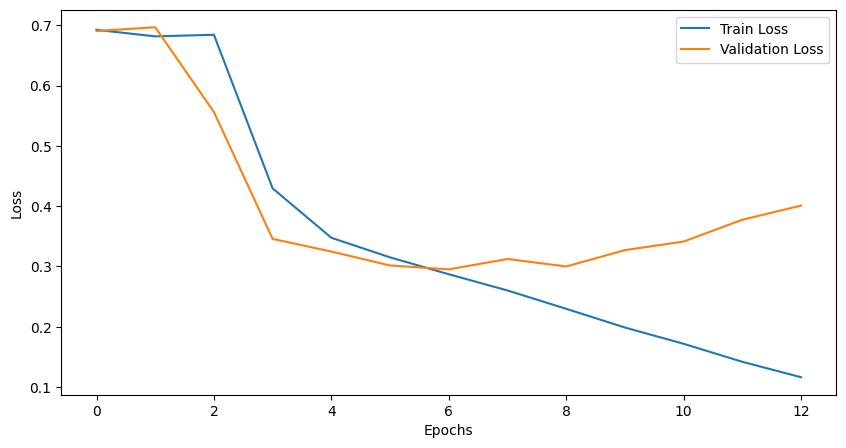

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(history_w2v.history['loss'], label='Train Loss')
plt.plot(history_w2v.history['val_loss'], label='Validation Loss')
plt.legend()
plt.xlabel('Epochs')
plt.ylabel('Loss')

In [ ]:
model_w2v.evaluate(X_test_padded,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.8685 - loss: 0.3165


[0.31650403141975403, 0.8684999942779541]

In [ ]:
y_pred_w2v = model_w2v.predict(X_test_padded)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step


In [ ]:
print(accuracy_score(y_test,y_pred_w2v.round()))

0.8685


In [ ]:
print(classification_report(y_test, y_pred_w2v.round()))


              precision    recall  f1-score   support

           0       0.88      0.85      0.87      4961
           1       0.86      0.88      0.87      5039

    accuracy                           0.87     10000
   macro avg       0.87      0.87      0.87     10000
weighted avg       0.87      0.87      0.87     10000



In [ ]:
print(confusion_matrix(y_test, y_pred_w2v.round()))

[[4230  731]
 [ 584 4455]]


Comparing with 3 models

In [ ]:
# Evaluate all models on test set
loss_rnn, acc_rnn = model_rnn.evaluate(X_test_padded, y_test, verbose=0)
loss_lstm, acc_lstm = lstm_model_v1.evaluate(X_test_padded, y_test, verbose=0)
loss_w2v, acc_w2v = model_w2v.evaluate(X_test_padded, y_test, verbose=0)

print(f"Model 1 (SimpleRNN)        - Accuracy: {acc_rnn:.4f}, Loss: {loss_rnn:.4f}")
print(f"Model 2 (LSTM)             - Accuracy: {acc_lstm:.4f}, Loss: {loss_lstm:.4f}")
print(f"Model 3 (LSTM + Word2Vec)  - Accuracy: {acc_w2v:.4f}, Loss: {loss_w2v:.4f}")

Model 1 (SimpleRNN)        - Accuracy: 0.5064, Loss: 0.6928
Model 2 (LSTM)             - Accuracy: 0.8831, Loss: 0.3049
Model 3 (LSTM + Word2Vec)  - Accuracy: 0.8685, Loss: 0.3165


**Error Analysis**

In [ ]:
import numpy as np
import pandas as pd

# Get predictions from best model (Model 3)
y_pred_probs = model_w2v.predict(X_test_padded)
y_pred = (y_pred_probs > 0.5).astype(int).flatten()
y_true = y_test.flatten()

# Find misclassified indices
misclassified_idx = np.where(y_pred != y_true)[0]
print(f"Total misclassified: {len(misclassified_idx)} out of {len(y_true)}")
print(f"Misclassification rate: {len(misclassified_idx)/len(y_true)*100:.2f}%")

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step
Total misclassified: 1315 out of 10000
Misclassification rate: 13.15%


In [ ]:
import numpy as np
import pandas as pd

# Get predictions from best model (Model 2)
y_pred_probs = lstm_model_v1.predict(X_test_padded)
y_pred = (y_pred_probs > 0.5).astype(int).flatten()
y_true = y_test.flatten()

# Find misclassified indices
misclassified_idx = np.where(y_pred != y_true)[0]
print(f"Total misclassified: {len(misclassified_idx)} out of {len(y_true)}")
print(f"Misclassification rate: {len(misclassified_idx)/len(y_true)*100:.2f}%")

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step
Total misclassified: 1169 out of 10000
Misclassification rate: 11.69%


In [ ]:
import numpy as np
import pandas as pd

# Get predictions from best model (Model 3)
y_pred_probs = model_rnn.predict(X_test_padded)
y_pred = (y_pred_probs > 0.5).astype(int).flatten()
y_true = y_test.flatten()

# Find misclassified indices
misclassified_idx = np.where(y_pred != y_true)[0]
print(f"Total misclassified: {len(misclassified_idx)} out of {len(y_true)}")
print(f"Misclassification rate: {len(misclassified_idx)/len(y_true)*100:.2f}%")

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step
Total misclassified: 4936 out of 10000
Misclassification rate: 49.36%


**GUI**

For GUI we will be using the best model out of three i.e LSTM model

### Sentiment Prediction GUI

In [ ]:
from IPython.display import display
import ipywidgets as widgets

# Create a text area for input
review_input = widgets.Textarea(
    value='',
    placeholder='Enter your movie review here...',
    description='Movie Review:',
    disabled=False,
    layout={'height': '150px', 'width': '500px'}
)

# Create a button for prediction
predict_button = widgets.Button(
    description='Predict Sentiment',
    disabled=False,
    button_style='success', # 'success', 'info', 'warning', 'danger' or ''
    tooltip='Click to predict sentiment',
    icon='check'
)

# Create an output widget to display results
output = widgets.Output()

def on_button_click(b):
    with output:
        output.clear_output()
        review_text = review_input.value.strip()

        if not review_text:
            print("Please enter a movie review.")
            return

        # Preprocess the input text using the existing pipeline
        cleaned_review = clean_text_pipeline(review_text)

        # Tokenize and pad the sequence
        sequence = tokenizer.texts_to_sequences([cleaned_review])
        padded_sequence = pad_sequences(sequence, maxlen=max_len, padding='post', truncating='post')

        # Make prediction using lstm_model_v1
        prediction = lstm_model_v1.predict(padded_sequence)[0][0]
        sentiment = "Positive" if prediction > 0.5 else "Negative"
        probability = prediction if prediction > 0.5 else (1 - prediction)

        print(f"Prediction: {sentiment} (Confidence: {probability:.2f})")

# Attach the button click event to the function
predict_button.on_click(on_button_click)

# Display the widgets
display(review_input, predict_button, output)

Textarea(value='', description='Movie Review:', layout=Layout(height='150px', width='500px'), placeholder='Ent…

Button(button_style='success', description='Predict Sentiment', icon='check', style=ButtonStyle(), tooltip='Cl…

Output()